<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Exercise.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

# Exercise: Principal component analysis
© ExploreAI Academy

In this exercise, we apply PCA to a dataset, evaluate the cumulative variance explained, and determine the appropriate number of components to retain.

## Learning objectives

By the end of this train, you should be able to:
* Apply PCA to reduce a dataset’s dimensionality.
* Evaluate the cumulative variance explained by each principal component.
* Determine the number of components needed to capture at least 85% of the variance. 

## Overview

The Digits dataset consists of 1,797 images of handwritten digits, each represented by a 64-dimensional feature vector. The dataset's high dimensionality can pose challenges when visualising and exploring it and could also lead to model complexity.

In this exercise, we apply PCA to the Digits dataset and evaluate its ability to reduce the dataset's dimensionality while retaining valuable information.

## Import libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Load and prepare dataset

In [2]:
# Load the dataset
digits = load_digits()
X = digits.data
y = digits.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Exercises

### Exercise 1

To reduce the dataset's dimensionality, let's transform the standardised dataset by applying PCA.

In [4]:
# Your solution here...

pca = PCA()

principal_components = pca.fit_transform(X_scaled)


### Exercise 2

To understand which components carry the most information, we can assess how much of the dataset's variance is captured by each principal component.

Compute and print the `Explained Variance Ratio` for each principal component formatted to four decimal places.

[1.20339161e-01 9.56105440e-02 8.44441489e-02 6.49840791e-02
 4.86015488e-02 4.21411987e-02 3.94208280e-02 3.38938092e-02
 2.99822101e-02 2.93200255e-02 2.78180546e-02 2.57705509e-02
 2.27530332e-02 2.22717974e-02 2.16522943e-02 1.91416661e-02
 1.77554709e-02 1.63806927e-02 1.59646017e-02 1.48919119e-02
 1.34796957e-02 1.27193137e-02 1.16583735e-02 1.05764660e-02
 9.75315947e-03 9.44558990e-03 8.63013827e-03 8.36642854e-03
 7.97693248e-03 7.46471371e-03 7.25582151e-03 6.91911245e-03
 6.53908536e-03 6.40792574e-03 5.91384112e-03 5.71162405e-03
 5.23636803e-03 4.81807586e-03 4.53719260e-03 4.23162753e-03
 4.06053070e-03 3.97084808e-03 3.56493303e-03 3.40787181e-03
 3.27835335e-03 3.11032007e-03 2.88575294e-03 2.76489264e-03
 2.59174941e-03 2.34483006e-03 2.18256858e-03 2.03597635e-03
 1.95512426e-03 1.83318499e-03 1.67946387e-03 1.61236062e-03
 1.47762694e-03 1.35118411e-03 1.25100742e-03 1.03695730e-03
 8.25350945e-04 9.10778070e-19 0.00000000e+00 0.00000000e+00]


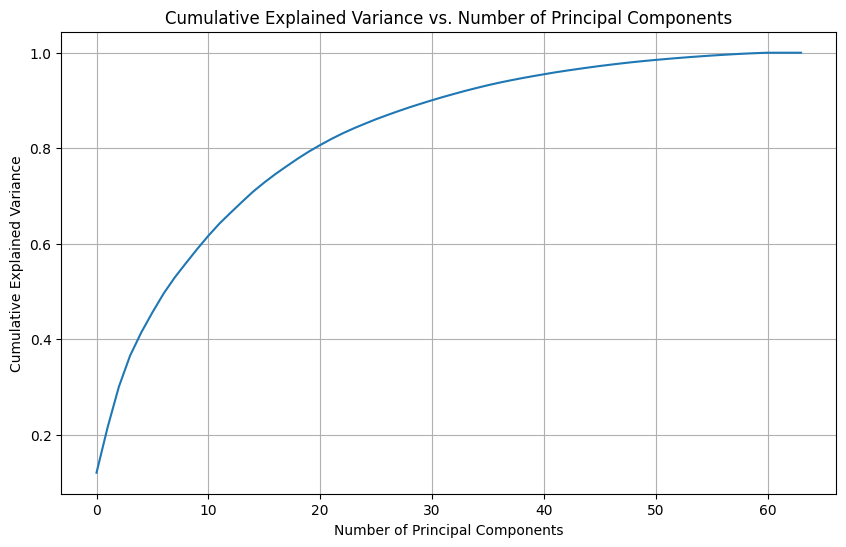

In [7]:
# Your solution here...
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))

plt.plot(cumulative_explained_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')
plt.grid()
plt.show()

### Exercise 3

We can also evaluate how much total variance is captured as components are added incrementally. This can help us get a view of how many components are needed to capture a substantial proportion of the dataset's variance.

Determine the cumulative variance ratio by summing the explained variance ratios of each principal component.

In [18]:
# Your solution here...
k = pd.DataFrame(cumulative_explained_variance, columns=['Cumulative Explained Variance'], index=[f'PC{i+1}' for i in range(len(cumulative_explained_variance))])
k.sort_values(by='Cumulative Explained Variance', ascending=True).head(30)

,Cumulative Explained Variance
PC1,0.120339
PC2,0.215950
PC3,0.300394
PC4,0.365378
PC5,0.413979
PC6,0.456121
PC7,0.495542
PC8,0.529435
PC9,0.559418
PC10,0.588738


### Exercise 4

Based on the results from **Exercise 3**, determine how many components are needed to capture at least 85% of the total variance.

Discuss the impact of this on subsequent analysis or modeling.

## Solutions

### Exercise 1

In [ ]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

### Exercise 2

In [ ]:
# Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Print the explained variance ratio
for i, ev in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: Explained Variance = {ev:.4f}")

The explained variance ratios show that the first few principal components (PC1, PC2, PC3) capture the most variance, with PC1 accounting for 12.03%. As we move to higher components, the explained variance decreases, indicating they carry less information about the dataset's overall variance.

### Exercise 3

In [ ]:
# Calculate the cumulative variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Print the cumulative variance ratio
for i, cv in enumerate(cumulative_variance_ratio):
    print(f"PC{i+1}: Cumulative Variance = {cv:.4f}")

The results show that each additional principal component captures more variance. For example, PC1 captures 12.03%, and by PC10, 58.87% is captured. All 64 components capture 100% variance. This helps identify how many components are needed to capture a significant portion of the dataset's variance.

### Exercise 4

The cumulative variance ratio shows that to reach at least 85% cumulative variance, 25 components are needed.

We observe that by retaining the first 25 components, we can capture 85.13% of the total variance in the dataset, which significantly reduces the dataset's dimensionality while retaining most of its information.

Using 25 components instead of the original 64 simplifies any downstream models by reducing their feature space, potentially improving model performance and interpretability.

The reduced number of components also makes visualising the data easier, which can provide meaningful insights into class separations or clustering.

Therefore, the ability to capture over 85% of the variance with 25 components makes PCA a viable dimensionality reduction technique for this dataset, preserving most information while simplifying further analyses.

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>